### LIB

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from scipy.stats import ttest_rel
import shap
import lightgbm as lgb
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import mannwhitneyu

In [4]:
df =  pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Data_No_PreProcessing.csv')
df

,Diagnosi alla dimissione (ICD code),Procedura (ICD code),Accesso chirurgico,Età,Sesso,Professione,BMI Pre-Int,Durata ricovero,ASA,Durata intervento,...,Hb ingresso,Durata CC riabilitazione,Outcome sociale,Peso Assistenziale,BI_post_int,FIM_post_int,Autonomia Deambulazione,Ausili,Outcome Sociale bin,Peso Assistenziale bin
0,715.16,81.54,pararotuleo,79.0,F,Pensionato Che Ha Lavorato,24.0,6.0,2,95.0,...,9.4,15.0,Istituto,Meno di 3h,84.0,109.0,Autonomo,2 canadesi,0,1
1,715.16,81.54,pararotuleo,73.0,F,Pensionato Che Ha Lavorato,26.0,6.0,2,121.0,...,9.0,16.0,Domicilio con parenti,Meno di 3h,100.0,118.0,Autonomo,2 canadesi,1,1
2,715.15,81.51,postero-laterale,73.0,F,Pensionato Che Ha Lavorato,23.0,6.0,1,88.0,...,10.1,10.0,Domicilio con parenti,Meno di 3h,84.0,107.0,Con supervisore,2 canadesi,1,1
3,715.16,81.54,pararotuleo,81.0,F,Pensionato Che Ha Lavorato,38.0,6.0,2,99.0,...,8.8,20.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi,1,0
4,715.25,81.51,postero-laterale,74.0,F,Pensionato Che Ha Lavorato,17.0,6.0,3,106.0,...,8.6,18.0,Istituto,Meno di 3h,99.0,115.0,Autonomo,2 canadesi,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1567,715.15,81.51,anteriore,63.0,M,Pensionato Che Ha Lavorato,26.0,5.0,1,68.0,...,12.1,12.0,Domicilio con parenti,Meno di 3h,99.0,115.0,Autonomo,2 canadesi,1,1
1568,715.16,81.54,pararotuleo,60.0,M,Imprenditore - Libero Professionista,26.0,3.0,2,31.0,...,10.6,6.0,Domicilio con parenti,Meno di 3h,95.0,118.0,Autonomo,2 canadesi,1,1
1569,715.25,81.51,laterale diretto,79.0,F,Pensionato Che Ha Lavorato,21.0,5.0,2,96.0,...,9.3,13.0,Domicilio con parenti,Nessuno,95.0,114.0,Autonomo,2 canadesi,1,0
1570,715.16,81.54,pararotuleo,49.0,M,Imprenditore - Libero Professionista,24.0,4.0,2,72.0,...,10.0,5.0,Domicilio con parenti,Meno di 3h,97.0,112.0,Autonomo,2 canadesi,1,1


In [5]:
df.columns

Index(['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)',
       'Accesso chirurgico', 'Età', 'Sesso', 'Professione', 'BMI Pre-Int',
       'Durata ricovero', 'ASA', 'Durata intervento', 'Anestesia',
       'Rischio bio', 'Trasfusione', 'BI', 'FIM', 'ADL',
       'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con',
       'Dolore ingresso (VNS)', 'Precedente protesi',
       'Condizioni pre-esistenti 1', 'Condizioni pre-esistenti 2',
       'Condizioni pre-esistenti 3', 'Condizioni pre-esistenti 4',
       'Condizioni pre-esistenti 5', 'Condizioni pre-esistenti 6',
       'Condizioni pre-esistenti 7', 'Condizioni pre-esistenti 8',
       'Condizioni pre-esistenti 9', 'Terapia farmacologica', 'Farmaci extra',
       'Hb ingresso', 'Durata CC riabilitazione', 'Outcome sociale',
       'Peso Assistenziale', 'BI_post_int', 'FIM_post_int',
       'Autonomia Deambulazione', 'Ausili', 'Outcome Sociale bin',
       'Peso Assistenziale bin'],
      dtype='object')

## 0: FIXED BINARY FEATURES

In [6]:
# Create binary variables
df['Sesso_F'] = df['Sesso'].map({'M':0, 'F':1})
df['Rischio_bio_bin'] = df['Rischio bio'].map({'No':0, 'Sì':1})
df['Trasfusione_bin'] = df['Trasfusione'].map({'No':0, 'Sì':1})
df['Farmaci_extra_bin'] = df['Farmaci extra'].map({'No':0, 'Sì':1})

# Professione → Sedentarieta
sedentary = ['Pensionato Che Ha Lavorato',
             'Casalinga (Che Non Ha Mai Svolto Lavoro Retribuito)',
             'Disoccupato (Attualmente)',
             'Invalido, Inabile (Anche Se Pensionato)',
             'Altro (Che Non Ha Mai Svolto Lavoro Retribuito)']

df['Sedentarieta'] = (~df['Professione'].isin(sedentary)).astype(int)

## 1: TRAIN E SPLIT

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Sesso"]) 

## 2: OHE

In [8]:
categorical_cols = ['Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)', 'Accesso chirurgico', 
                    'Anestesia', 'ADL', 'L Autonomia passaggi posturali',
                    'Ausili Deambulazione', 'Vive con', 'Precedente protesi']

# One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on training set
train_ohe = ohe.fit_transform(train_df[categorical_cols])

# Transform test set
test_ohe = ohe.transform(test_df[categorical_cols])

# Get feature names
ohe_columns = ohe.get_feature_names_out(categorical_cols)

# Convert to DataFrame
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_columns, index=train_df.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_columns, index=test_df.index)

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [9]:
# ==============================
# STEP 2b: INTERACTIONS CATEGORIALI / BINARY
# ==============================
# Esempio: sesso × anestesia
train_df['Sesso_Anestesia'] = train_df['Sesso'] + '_' + train_df['Anestesia']
test_df['Sesso_Anestesia'] = test_df['Sesso'] + '_' + test_df['Anestesia']

# Aggiungi al set di OHE
categorical_cols.append('Sesso_Anestesia')
ohe2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
train_ohe2 = ohe2.fit_transform(train_df[['Sesso_Anestesia']])
test_ohe2 = ohe2.transform(test_df[['Sesso_Anestesia']])
ohe2_columns = ohe2.get_feature_names_out(['Sesso_Anestesia'])

train_ohe2_df = pd.DataFrame(train_ohe2, columns=ohe2_columns, index=train_df.index)
test_ohe2_df = pd.DataFrame(test_ohe2, columns=ohe2_columns, index=test_df.index)

## STEP 3: BINARY MATRIX FOR PRE-EXISTING CONDITIONS

In [10]:
# Collect all pre-existing conditions in training set
pre_cols = [f'Condizioni pre-esistenti {i}' for i in range(1,10)]

# Get unique conditions excluding "Missing"
unique_conditions = set(train_df[pre_cols].values.ravel())
unique_conditions.discard('Missing')
# ensure stable ordering
unique_conditions = sorted(unique_conditions)

# Function to create binary matrix
def create_condition_matrix(df, pre_cols, unique_conditions):
    # create zero matrix with one column per unique condition
    df_cond = pd.DataFrame(0, index=df.index, columns=unique_conditions)
    # for each condition, mark rows where any of the pre_cols equals that condition
    for cond in unique_conditions:
        df_cond[cond] = df[pre_cols].eq(cond).any(axis=1).astype(int)
    return df_cond

train_cond_df = create_condition_matrix(train_df, pre_cols, unique_conditions)
test_cond_df = create_condition_matrix(test_df, pre_cols, unique_conditions)

In [11]:
# ==============================
# STEP 3b: INDICATORI E CONTEGGI CONDIZIONI
# ==============================
train_df['N_condizioni'] = train_cond_df.sum(axis=1)
test_df['N_condizioni'] = test_cond_df.sum(axis=1)

train_df['No_condizioni'] = (train_cond_df.sum(axis=1) == 0).astype(int)
test_df['No_condizioni'] = (test_cond_df.sum(axis=1) == 0).astype(int)

## STEP 4: IMPUTATION OF 'Terapia farmacologica'

In [12]:
# Map categorical responses to numeric
therapy_map = {'No': 0, 'In parte': 0.5, 'Sì': 1}
train_df['Terapia_farm_num'] = train_df['Terapia farmacologica'].map(therapy_map)
test_df['Terapia_farm_num'] = test_df['Terapia farmacologica'].map(therapy_map)

# Now you can use IterativeImputer or KNNImputer
num_cols = ['Terapia_farm_num']

# MICE imputer
mice_imputer = IterativeImputer(random_state=42)
train_mice = mice_imputer.fit_transform(train_df[num_cols])
test_mice = mice_imputer.transform(test_df[num_cols])

# KNN imputer
knn_imputer = KNNImputer()
train_knn = knn_imputer.fit_transform(train_df[num_cols])
test_knn = knn_imputer.transform(test_df[num_cols])

# Funzione per arrotondare ai valori 0, 0.5, 1
def round_therapy_values(x):
    return np.array([min([0, 0.5, 1], key=lambda y: abs(y - val)) for val in x])

# Applica la funzione sulle colonne imputate
train_mice_rounded = round_therapy_values(train_mice.ravel())
test_mice_rounded = round_therapy_values(test_mice.ravel())

# Converti in DataFrame
train_mice_df = pd.DataFrame(train_mice_rounded, columns=['Terapia_farm_num'], index=train_df.index)
test_mice_df = pd.DataFrame(test_mice_rounded, columns=['Terapia_farm_num'], index=test_df.index)

## STEP 5: STANDARDIZATION OF NUMERIC FEATURES

In [13]:
numeric_cols = ['Età', 'BMI Pre-Int', 'Durata ricovero',"Durata intervento", "BI", "FIM", "Hb ingresso"]  

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[numeric_cols])
test_scaled = scaler.transform(test_df[numeric_cols])

train_scaled_df = pd.DataFrame(train_scaled, columns=numeric_cols, index=train_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=numeric_cols, index=test_df.index)

In [14]:
# ==============================
# STEP 5b: FEATURE DERIVATE NUMERICHE
# ==============================

# (A) Interazioni numeriche sulle variabili standardizzate
train_interactions = pd.DataFrame({
    'Età_x_BMI': train_scaled_df['Età'] * train_scaled_df['BMI Pre-Int'],
    'DurataRicovero_x_Intervento': train_scaled_df['Durata ricovero'] * train_scaled_df['Durata intervento'],
    'BI_div_FIM': train_scaled_df['BI'] / (train_scaled_df['FIM'] + 1e-6),
    'Età_x_Hb': train_scaled_df['Età'] * train_scaled_df['Hb ingresso'],
    'BMI_x_DurataIntervento': train_scaled_df['BMI Pre-Int'] * train_scaled_df['Durata intervento']
}, index=train_df.index)

test_interactions = pd.DataFrame({
    'Età_x_BMI': test_scaled_df['Età'] * test_scaled_df['BMI Pre-Int'],
    'DurataRicovero_x_Intervento': test_scaled_df['Durata ricovero'] * test_scaled_df['Durata intervento'],
    'BI_div_FIM': test_scaled_df['BI'] / (test_scaled_df['FIM'] + 1e-6),
    'Età_x_Hb': test_scaled_df['Età'] * test_scaled_df['Hb ingresso'],
    'BMI_x_DurataIntervento': test_scaled_df['BMI Pre-Int'] * test_scaled_df['Durata intervento']
}, index=test_df.index)

# (D) Efficienza intervento come ratio (standardizzata)
train_eff = pd.DataFrame({
    'Efficienza_intervento': train_scaled_df['Durata intervento'] / (train_scaled_df['Durata ricovero'] + 1e-6)
}, index=train_df.index)

test_eff = pd.DataFrame({
    'Efficienza_intervento': test_scaled_df['Durata intervento'] / (test_scaled_df['Durata ricovero'] + 1e-6)
}, index=test_df.index)

# ------------------------------
# (E) Trasformazioni non lineari
# log su Durata intervento (dati originali)
# quadrato su BMI standardizzato
# ------------------------------
# logaritmo e quadrato su variabili numeric standardizzate
train_nonlinear = pd.DataFrame({
    'log_DurataIntervento': np.log1p(train_df['Durata intervento']),
    'BMI_quadrato': train_scaled_df['BMI Pre-Int'] ** 2,
    'Età_quadrato': train_scaled_df['Età'] ** 2,
    'Hb_sqrt': np.sqrt(train_df['Hb ingresso'])
}, index=train_df.index)

test_nonlinear = pd.DataFrame({
    'log_DurataIntervento': np.log1p(test_df['Durata intervento']),
    'BMI_quadrato': test_scaled_df['BMI Pre-Int'] ** 2,
    'Età_quadrato': test_scaled_df['Età'] ** 2,
    'Hb_sqrt': np.sqrt(test_df['Hb ingresso'])
}, index=test_df.index)

# standardizzazione dopo trasformazioni
scaler_nl = StandardScaler()
train_nonlinear = pd.DataFrame(scaler_nl.fit_transform(train_nonlinear), columns=train_nonlinear.columns, index=train_df.index)
test_nonlinear = pd.DataFrame(scaler_nl.transform(test_nonlinear), columns=test_nonlinear.columns, index=test_df.index)



## STEP 6: COMBINE ALL TRANSFORMED FEATURES

In [15]:
# ==============================
# STEP 6: CONCATENAZIONE FINALE DELLE FEATURE
# ==============================

fixed_binary_cols = [
    'Sesso_F', 'Rischio_bio_bin', 'Trasfusione_bin', 
    'Farmaci_extra_bin', 'Sedentarieta', 'No_condizioni', 'N_condizioni'
]

# --- TRAIN SET ---
train_final_imputation = pd.concat([
    train_df[fixed_binary_cols],   # binary fisse
    train_ohe_df,                  # OHE categoriali principali
    train_ohe2_df,                 # eventuali OHE aggiuntive
    train_cond_df,                 # condizioni pre-esistenti binarie
    train_scaled_df,               # variabili numeriche standardizzate
    train_interactions,            # interazioni numeriche standardizzate
    train_eff,                     # efficienza intervento standardizzata
    train_nonlinear,               # trasformazioni non lineari standardizzate
    train_mice_df                  # Terapia farmacologica imputata
], axis=1)

train_final_no_imputation = pd.concat([
    train_df[fixed_binary_cols],
    train_ohe_df,
    train_ohe2_df,
    train_cond_df,
    train_scaled_df,
    train_interactions,
    train_eff,
    train_nonlinear,
    train_df['Terapia_farm_num']  # senza imputazione
], axis=1)

# --- TEST SET ---
test_final_imputation = pd.concat([
    test_df[fixed_binary_cols],
    test_ohe_df,
    test_ohe2_df,
    test_cond_df,
    test_scaled_df,
    test_interactions,
    test_eff,
    test_nonlinear,
    test_mice_df
], axis=1)

test_final_no_imputation = pd.concat([
    test_df[fixed_binary_cols],
    test_ohe_df,
    test_ohe2_df,
    test_cond_df,
    test_scaled_df,
    test_interactions,
    test_eff,
    test_nonlinear,
    test_df['Terapia_farm_num']
], axis=1)

print("Preprocessing complete.")
print("Train shape (with imputation):", train_final_imputation.shape)
print("Train shape (without imputation):", train_final_no_imputation.shape)
print("Test shape (with imputation):", test_final_imputation.shape)
print("Test shape (without imputation):", test_final_no_imputation.shape)


Preprocessing complete.
Train shape (with imputation): (1257, 86)
Train shape (without imputation): (1257, 86)
Test shape (with imputation): (315, 86)
Test shape (without imputation): (315, 86)


# Modeling

In [16]:
# Target
y_train = train_df['Durata CC riabilitazione']
y_test = test_df['Durata CC riabilitazione']

# Features
X_train = train_final_imputation  
X_test = test_final_imputation    


## Correlazione con la target

C:\Users\fccat\AppData\Local\Temp\ipykernel_20360\1702073813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")


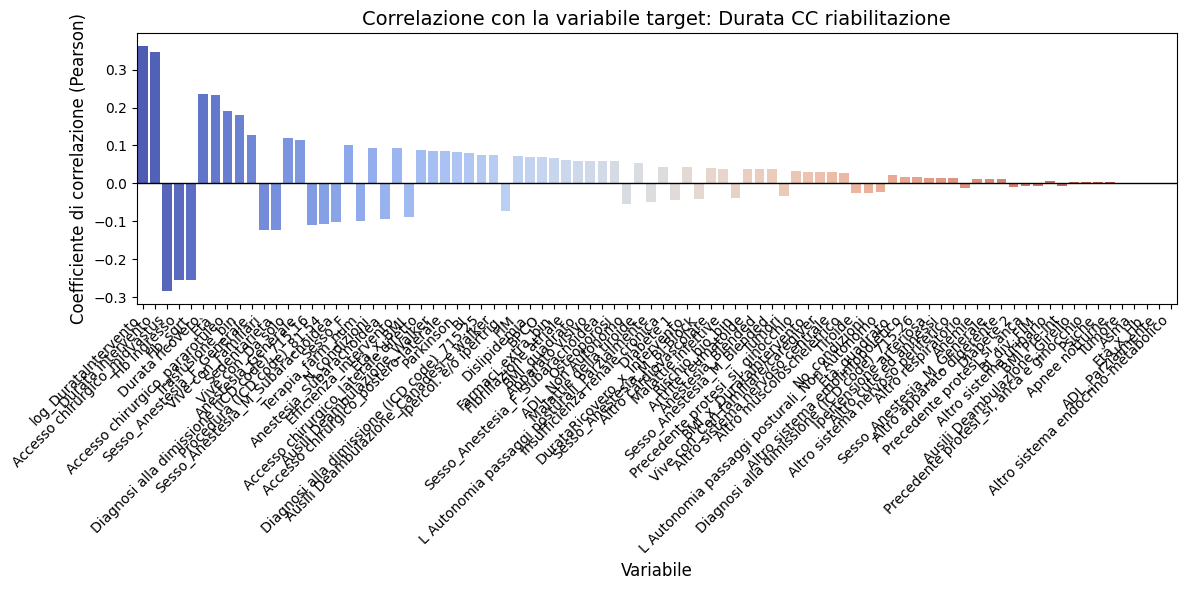

In [17]:

# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Durata CC riabilitazione")], axis=1)

# Calcola correlazione solo con la variabile target
corr_target = df_corr.corr()["Durata CC riabilitazione"].drop("Durata CC riabilitazione")

# Ordina per valore assoluto
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Grafico verticale
plt.figure(figsize=(12, 6))
sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")
plt.axhline(0, color='black', lw=1)
plt.title("Correlazione con la variabile target: Durata CC riabilitazione", fontsize=14)
plt.ylabel("Coefficiente di correlazione (Pearson)", fontsize=12)
plt.xlabel("Variabile", fontsize=12)
plt.xticks(rotation=45, ha='right')  # ruota le etichette per leggerle
plt.tight_layout()
plt.show()

C:\Users\fccat\AppData\Local\Temp\ipykernel_20360\132272407.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


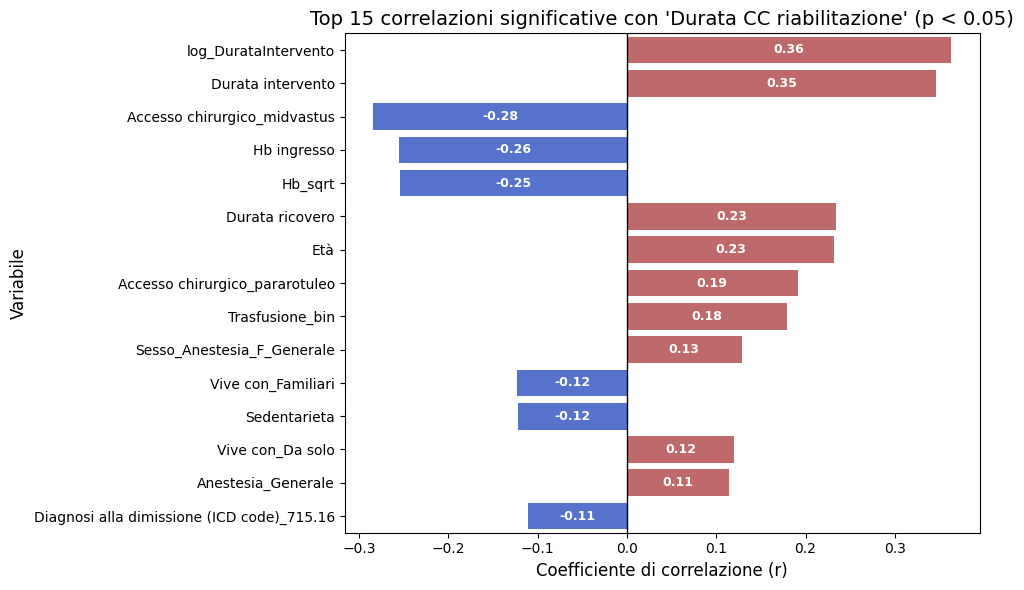

In [18]:
# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Durata CC riabilitazione")], axis=1)
target = "Durata CC riabilitazione"

# Calcola correlazione e p-value
corr_list = []
for col in X_train.columns:
    r, p = pearsonr(df_corr[col], df_corr[target])
    corr_list.append((col, r, p))

corr_df = pd.DataFrame(corr_list, columns=["Variabile", "r", "p_value"])

# Filtra solo correlazioni significative (p < 0.05)
p_cutoff = 0.05
corr_df_sig = corr_df[corr_df["p_value"] < p_cutoff]

# Mostra top N correlazioni per valore assoluto
top_n = 15
corr_df_sig = corr_df_sig.reindex(corr_df_sig["r"].abs().sort_values(ascending=False).head(top_n).index)

# Colori invertiti: rosso = positiva, blu = negativa
colors = ["indianred" if x > 0 else "royalblue" for x in corr_df_sig["r"]]

# Grafico orizzontale
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x="r",
    y="Variabile",
    data=corr_df_sig,
    palette=colors
)
plt.axvline(0, color='black', lw=1)
plt.title(f"Top {top_n} correlazioni significative con '{target}' (p < {p_cutoff})", fontsize=14)
plt.xlabel("Coefficiente di correlazione (r)", fontsize=12)
plt.ylabel("Variabile", fontsize=12)

# Aggiungi valori r dentro le barre
for bar, r_val in zip(bars.patches, corr_df_sig["r"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    x_pos = width / 2
    bars.text(
        x=x_pos,
        y=y_pos,
        s=f"{r_val:.2f}",
        ha='center',
        va='center',
        color='white',  # bianco per contrasto con i colori scuri
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Ridge 

In [19]:
# Definizione del modello Ridge

ridge = Ridge(random_state=42)

# Grid dei parametri alpha
param_grid = {
    'alpha': [0, 0.01, 0.1, 1, 10, 100]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# Visualizzare i risultati dettagliati per ogni alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# Modello finale con i migliori parametri
best_ridge = grid_search.best_estimator_

# Predizioni sul test set
y_pred_ridge = best_ridge.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }
# Valutazione finale
evaluate_model_with_ci(y_test, y_pred_ridge, "Ridge Regression (GridSearchCV)")


Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0         0.00    -4.360061e+25    5.153651e+25          0.319069   
1         0.01     1.743220e-01    5.448758e-02          0.340906   
2         0.10     1.799138e-01    5.195682e-02          0.340824   
3         1.00     2.030260e-01    4.147559e-02          0.338400   
4        10.00     2.268958e-01    3.053928e-02          0.326083   
5       100.00     2.440548e-01    2.083443e-02          0.304238   

   std_train_score  
0         0.039114  
1         0.009120  
2         0.009099  
3         0.008353  
4         0.005509  
5         0.003828  

Migliori hyper-parametri: {'alpha': 100}
Miglior punteggio CV (R²): 0.24405484987450757

Ridge Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.31  [2.07, 2.60]
  RMSE       = 3.22  [2.67, 3.84]
  R²         = 0.252  [0.156, 0.341]
  SD(target) = 3.72
  MAE/SD     = 

{'MAE': 2.3096128169337904,
 'MAE_CI': array([2.0694651 , 2.59815154]),
 'RMSE': np.float64(3.21830725113763),
 'RMSE_CI': array([2.6747411 , 3.83662388]),
 'R2': 0.25154712768536625,
 'R2_CI': array([0.1563011, 0.3412202]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6208603235743527),
 'RMSE/SD': np.float64(0.865131708073767)}

In [20]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                           Feature  Coefficient
68                             Età     0.813243
71               Durata intervento     0.766053
81            log_DurataIntervento     0.617731
12    Accesso chirurgico_midvastus    -0.610937
58          Ipercol. e/o ipertrig.    -0.403362
..                             ...          ...
39           Altro cute ed annessi    -0.005946
42  Altro sistema emolinfopoietico    -0.005917
23    Ausili Deambulazione_Girello    -0.001049
1                  Rischio_bio_bin     0.000563
82                    BMI_quadrato     0.000186

[86 rows x 2 columns]


In [21]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Età: 0.813
Durata intervento: 0.766
log_DurataIntervento: 0.618
Accesso chirurgico_midvastus: -0.611
Ipercol. e/o ipertrig.: -0.403


## Lasso

In [22]:

# ===============================
# 1️⃣ Definizione del modello Lasso
# ===============================
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter alto per garantire convergenza

# Grid dei parametri alpha
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_lasso = grid_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa della tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_lasso, "Lasso Regression (GridSearchCV)")



Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0       0.0001         0.175889        0.054120          0.340887   
1       0.0010         0.192057        0.048715          0.339631   
2       0.0100         0.236546        0.029977          0.317187   
3       0.1000         0.252388        0.018762          0.275642   
4       1.0000         0.054732        0.004566          0.057271   
5      10.0000        -0.001847        0.001925          0.000000   

   std_train_score  
0         0.009118  
1         0.009030  
2         0.004336  
3         0.004281  
4         0.007719  
5         0.000000  

Migliori hyper-parametri: {'alpha': 0.1}
Miglior punteggio CV (R²): 0.25238825251751357

Lasso Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.38  [2.13, 2.66]
  RMSE       = 3.27  [2.74, 3.91]
  R²         = 0.228  [0.136, 0.313]
  SD(target) = 3.72
  MAE/SD     = 

{'MAE': 2.3752676324095403,
 'MAE_CI': array([2.12872372, 2.65600313]),
 'RMSE': np.float64(3.268648098023501),
 'RMSE_CI': array([2.73548451, 3.90608277]),
 'R2': 0.22794936235461116,
 'R2_CI': array([0.13626609, 0.3126076 ]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6385093726624178),
 'RMSE/SD': np.float64(0.8786641210641236)}

In [23]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)

                         Feature  Coefficient
12  Accesso chirurgico_midvastus    -1.009451
68                           Età     0.787578
81          log_DurataIntervento     0.751703
71             Durata intervento     0.545064
84                       Hb_sqrt    -0.395114
..                           ...          ...
73                           FIM     0.000000
74                   Hb ingresso    -0.000000
78                      Età_x_Hb    -0.000000
82                  BMI_quadrato     0.000000
85              Terapia_farm_num    -0.000000

[86 rows x 2 columns]


In [24]:
# Esempio (ipotetico)
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

Accesso chirurgico_midvastus: -1.009
Età: 0.788
log_DurataIntervento: 0.752
Durata intervento: 0.545
Hb_sqrt: -0.395


## SVM

In [25]:


# ===============================
# 1️⃣ Definizione del modello SVR
# ===============================
svr = SVR()

# Grid dei parametri da testare
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'degree': [2, 3, 4]  # utile solo per kernel='poly'
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search_svr.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results_svr = pd.DataFrame(grid_search_svr.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di parametri:")
print(cv_results_svr[['param_kernel', 'param_C', 'param_epsilon', 'param_degree',
                      'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params_svr = grid_search_svr.best_params_
print("\nMigliori hyper-parametri:", best_params_svr)
print("Miglior punteggio CV (R²):", grid_search_svr.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione con CI (stessa che usi per RF e Lasso)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_svr, "Support Vector Regressor (GridSearchCV)")



Risultati della cross-validation per ogni combinazione di parametri:
    param_kernel  param_C  param_epsilon  param_degree  mean_test_score  \
0         linear      0.1           0.01             2         0.224072   
1           poly      0.1           0.01             2         0.115402   
2            rbf      0.1           0.01             2         0.191135   
3        sigmoid      0.1           0.01             2        -0.000770   
4         linear      0.1           0.10             2         0.223958   
..           ...      ...            ...           ...              ...   
187      sigmoid    100.0           0.50             4   -381099.469796   
188       linear    100.0           1.00             4         0.184677   
189         poly    100.0           1.00             4       -53.568987   
190          rbf    100.0           1.00             4         0.087102   
191      sigmoid    100.0           1.00             4   -381607.914795   

     std_test_score  mean_tra

{'MAE': 2.189245243883215,
 'MAE_CI': array([1.93673136, 2.45551958]),
 'RMSE': np.float64(3.1933010790273295),
 'RMSE_CI': array([2.63164518, 3.83388338]),
 'R2': 0.26313286433098826,
 'R2_CI': array([0.18269208, 0.34757244]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5885036230035393),
 'RMSE/SD': np.float64(0.8584096549253227)}

Top 10 Feature Importance (Permutation):
Efficienza_intervento: 0.0777
log_DurataIntervento: 0.0568
Durata intervento: 0.0300
Accesso chirurgico_midvastus: 0.0185
Durata ricovero: 0.0179
Età: 0.0149
N_condizioni: 0.0051
Accesso chirurgico_pararotuleo: 0.0045
FIM: 0.0037
Procedura (ICD code)_81.54: 0.0031


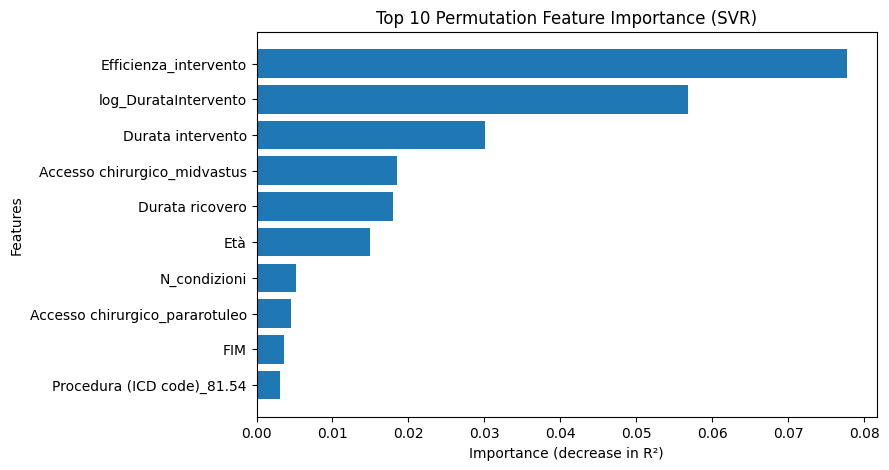

In [26]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_svr, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (SVR)")
plt.show()


## MLP

In [27]:
# =======================================
# 1️⃣ Import librerie aggiornate
# =======================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasRegressor  # ✅ sostituisce il vecchio wrapper
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# 2️⃣ Funzione per costruire il modello
# =======================================
def build_model(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# =======================================
# 3️⃣ Wrapping con scikeras
# =======================================
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)

# =======================================
# 4️⃣ Ricerca iperparametri
# =======================================
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [32, 64, 128],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ["adam", "rmsprop"],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100]
}

random_search = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# =======================================
# 5️⃣ Training
# =======================================
random_search.fit(X_train, y_train)

# Migliori parametri
print("\nBest Hyper-parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# =======================================
# 6️⃣ Predizioni
# =======================================
y_pred_dl = best_model.predict(X_test)

# =======================================
# 7️⃣ Valutazione (uguale alla tua)
# =======================================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

# =======================================
# 8️⃣ Valutazione finale
# =======================================
evaluate_model_with_ci(y_test, y_pred_dl, "Deep Learning Regressor (Keras MLP)")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyper-parameters: {'model__optimizer': 'rmsprop', 'model__n_neurons': 32, 'model__n_hidden': 2, 'model__lr': 0.0005, 'model__dropout_rate': 0.2, 'epochs': 50, 'batch_size': 32}

Deep Learning Regressor (Keras MLP) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.27  [2.03, 2.54]
  RMSE       = 3.21  [2.70, 3.78]
  R²         = 0.256  [0.148, 0.342]
  SD(target) = 3.72
  MAE/SD     = 0.611
  RMSE/SD    = 0.863


In [28]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (MLP)")
plt.show()


KeyboardInterrupt: 

## Random Forest

In [ ]:
# Definizione del modello base
rf_reg = RandomForestRegressor(random_state=42)

# Definizione del grid dei parametri da testare
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi usare anche 'neg_mean_absolute_error'
    n_jobs=-1
)

# Fit del GridSearch sul train set
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
best_params = grid_search.best_params_
print("Best Hyper-parameters:", best_params)

# Creiamo il modello finale con i migliori parametri
best_rf = grid_search.best_estimator_

# Predizioni sul test set
y_pred_rf = best_rf.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione del modello ottimizzato
evaluate_model_with_ci(y_test, y_pred_rf, "Random Forest Regressor (GridSearchCV)")

Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}

Random Forest Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.24  [1.97, 2.50]
  RMSE       = 3.25  [2.72, 3.85]
  R²         = 0.238  [0.140, 0.328]
  SD(target) = 3.72
  MAE/SD     = 0.602
  RMSE/SD    = 0.873


{'MAE': 2.2381358812156678,
 'MAE_CI': array([1.97329813, 2.49712049]),
 'RMSE': np.float64(3.247214087981143),
 'RMSE_CI': array([2.72256916, 3.84712264]),
 'R2': 0.23804153733797706,
 'R2_CI': array([0.14025172, 0.32843652]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6016461968113348),
 'RMSE/SD': np.float64(0.8729023213750912)}

                        feature  importance
0               Durata ricovero    0.190238
1                           Età    0.122368
2         Efficienza_intervento    0.080914
3   DurataRicovero_x_Intervento    0.074100
4        BMI_x_DurataIntervento    0.045417
5                   Hb ingresso    0.040818
6                       Hb_sqrt    0.040268
7          log_DurataIntervento    0.039405
8                      Età_x_Hb    0.038489
9             Durata intervento    0.037971
10                   BI_div_FIM    0.035637
11                    Età_x_BMI    0.034136
12                          FIM    0.031096
13                           BI    0.029896
14                 BMI_quadrato    0.017468


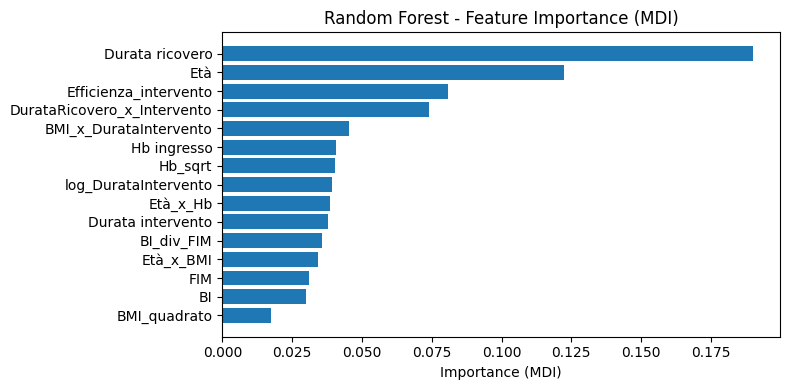

In [ ]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_rf è il modello preso da GridSearchCV (come nel tuo codice)
mdi_importances = best_rf.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(15))


# Grafico orizzontale top 15
top_n = 15
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Random Forest - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

## LightGBM

In [ ]:
# ----------------------------
# Pulizia dei nomi delle colonne (fondamentale per LightGBM)
# ----------------------------
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# ----------------------------
# Definizione del modello
# ----------------------------
lgb_reg = lgb.LGBMRegressor(random_state=42)

# ----------------------------
# Grid dei parametri da testare
# ----------------------------
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 5, 10, 20],          # -1 = nessun limite
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20]
}

# ----------------------------
# GridSearchCV con 5-fold CV
# ----------------------------
grid_search = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # mostra l’errore esatto in caso di fallimento
)

# ----------------------------
# Fit sul train set (con gestione errori)
# ----------------------------
try:
    grid_search.fit(X_train, y_train)
except Exception as e:
    print("❌ Errore durante il fit di GridSearchCV:")
    print(e)
    raise

# ----------------------------
# Migliori parametri trovati
# ----------------------------
best_params = grid_search.best_params_
print("\n✅ Best Hyper-parameters LightGBM:", best_params)

# ----------------------------
# Modello finale con i migliori parametri
# ----------------------------
best_lgb = grid_search.best_estimator_

# ----------------------------
# Predizioni sul test set
# ----------------------------
y_pred_lgb = best_lgb.predict(X_test)

# ----------------------------
# Valutazione con bootstrap CI
# ----------------------------
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n📊 {name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ----------------------------
# Valutazione finale LightGBM
# ----------------------------
evaluate_model_with_ci(y_test, y_pred_lgb, "LightGBM Regressor (GridSearchCV)")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,001512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2255
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 59
[LightGBM] [Info] Start training from score 10,232299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

{'MAE': 2.206719569864574,
 'MAE_CI': array([1.94602303, 2.47850591]),
 'RMSE': np.float64(3.231268673115169),
 'RMSE_CI': array([2.68840861, 3.85928956]),
 'R2': 0.24550634431830287,
 'R2_CI': array([0.15571006, 0.33331839]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.5932009972142667),
 'RMSE/SD': np.float64(0.8686159425670801)}

Top 10 features (LightGBM - gain):
                        feature  importance
68                          Et_         543
74                  Hb_ingresso         479
71            Durata_intervento         440
76  DurataRicovero_x_Intervento         406
80        Efficienza_intervento         400
79       BMI_x_DurataIntervento         348
77                   BI_div_FIM         289
78                     Et__x_Hb         231
73                          FIM         209
75                    Et__x_BMI         181


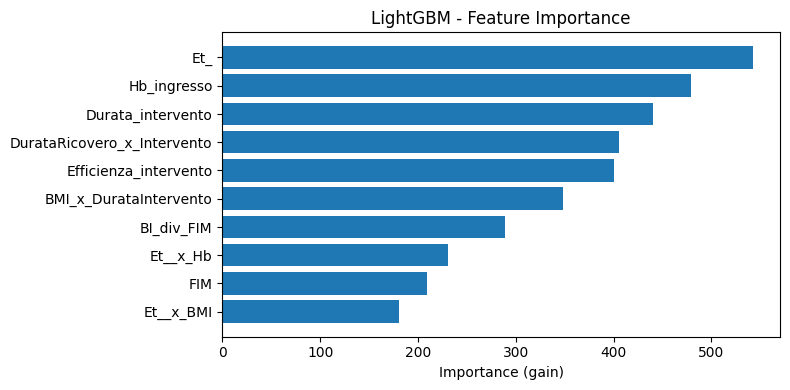

In [ ]:
# ----------------------------
# Feature importance basata sul gain
# ----------------------------
gain_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_lgb.feature_importances_  # default è "split", ma puoi usare best_lgb.booster_.feature_importance('gain') per il gain
}).sort_values('importance', ascending=False)

print("Top 10 features (LightGBM - gain):")
print(gain_importance.head(10))

# Grafico
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(gain_importance['feature'].head(top_n)[::-1], gain_importance['importance'].head(top_n)[::-1])
plt.xlabel('Importance (gain)')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()


## Decision Tree

In [29]:
# ===============================
# 1️⃣ Definizione del modello Decision Tree
# ===============================
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid dei parametri da testare
param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi cambiare in 'neg_mean_absolute_error' se preferisci
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di iperparametri:")
print(cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
                  'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_dt, "Decision Tree Regressor (GridSearchCV)")


Risultati della cross-validation per ogni combinazione di iperparametri:
   param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0             None                        2                       1   
1             None                        5                       1   
2             None                       10                       1   
3             None                        2                       2   
4             None                        5                       2   
5             None                       10                       2   
6             None                        2                       4   
7             None                        5                       4   
8             None                       10                       4   
9                5                        2                       1   
10               5                        5                       1   
11               5                       10                       1   
12 

{'MAE': 2.3156337058901664,
 'MAE_CI': array([2.06137147, 2.59686654]),
 'RMSE': np.float64(3.3555787780532347),
 'RMSE_CI': array([2.83193349, 3.9657011 ]),
 'R2': 0.1863374450001528,
 'R2_CI': array([0.08304671, 0.2770777 ]),
 'SD_target': np.float64(3.7200199936068175),
 'MAE/SD': np.float64(0.6224788334121287),
 'RMSE/SD': np.float64(0.9020324578416494)}

In [ ]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_dt è il modello preso da GridSearchCV 
mdi_importances = best_dt.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(10))


# Grafico orizzontale top 15
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Decision Tree - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Crea un oggetto explainer specifico per modelli tree-based
explainer = shap.TreeExplainer(best_dt)

# 2. Calcola i valori SHAP (quanto ciascuna feature contribuisce alla predizione per ogni campione)
shap_values = explainer.shap_values(X_test)

# 3. Ottieni anche i valori predetti e la base line (expected value)
expected_value = explainer.expected_value
print(f"Expected value (base prediction): {np.ravel(expected_value)[0]:.3f}")

# Calcola l'importanza media assoluta di ogni feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Crea un DataFrame per ordinarle
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Seleziona le prime 10 feature più importanti
top_features = shap_importance['feature'].head(10).tolist()

# Filtra i dati SHAP e X_test sulle prime 10 feature
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]
print("Top 10 features (SHAP):")
print(shap_importance.head(10))
# Plot con solo le prime 10
shap.summary_plot(shap_values_top, X_test_top, plot_type="bar")
shap.summary_plot(shap_values_top, X_test_top)